# VOC-Detection Dataset

In [1]:
from typing import Tuple

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

import torch

from src import VOC, TrainTransform

In [2]:
ROOT = "./voc"
IMAGE_SET = "train"
DOWNLOAD = True
IMG_SIZE = (640, 640)
SEED = 0
TRANSFORM = TrainTransform(size=IMG_SIZE)

In [3]:
np.random.seed(SEED)
torch.manual_seed(SEED)

## Visualizing training data

In [4]:
def cxcywh_to_xywh(box: np.ndarray) -> np.ndarray:
    box = box.copy()

    cx, cy = box[0], box[1]
    w, h = box[2], box[3]

    x = cx - w / 2
    y = cy - h / 2

    box[0], box[1] = x, y

    return box


def to_img_scale(box: np.ndarray, img_size: Tuple[int, int]) -> np.ndarray:
    box = box.copy() 

    width, height = img_size

    box[0] *= width
    box[1] *= height
    box[2] *= width
    box[3] *= height

    return box

In [5]:
dataset = VOC(ROOT, image_set=IMAGE_SET, download=DOWNLOAD)

In [6]:
print(f"VOCDetection training set with: {len(dataset)} samples")

VOCDetection training set with: 16551 samples


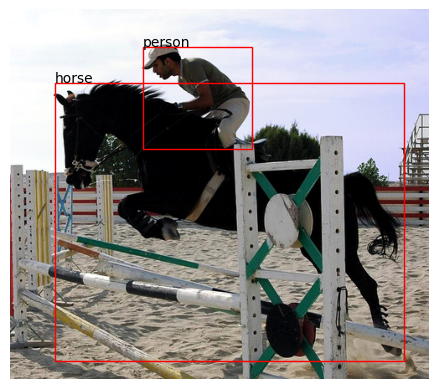

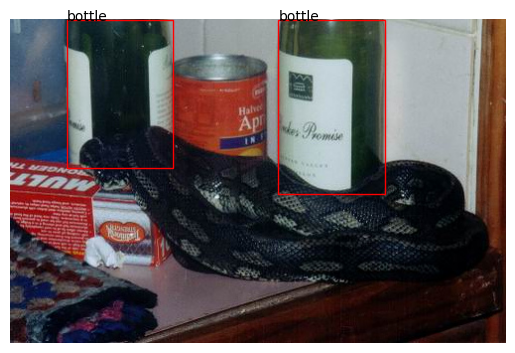

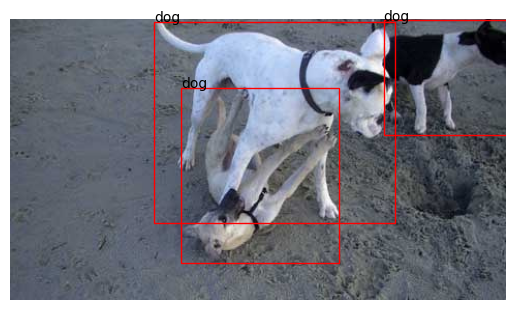

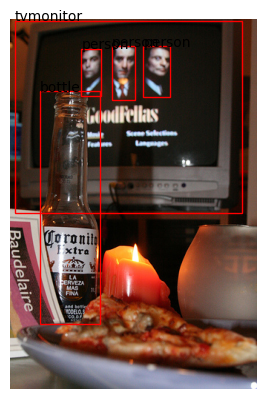

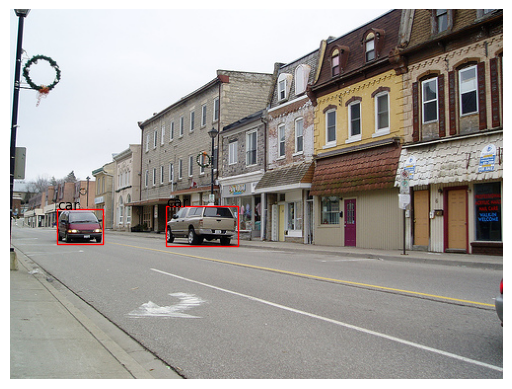

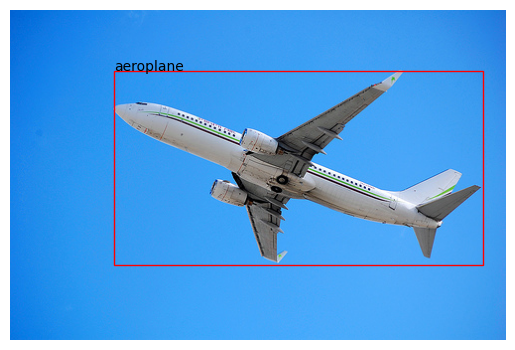

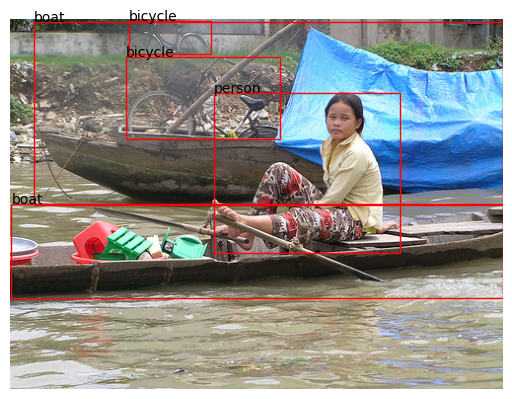

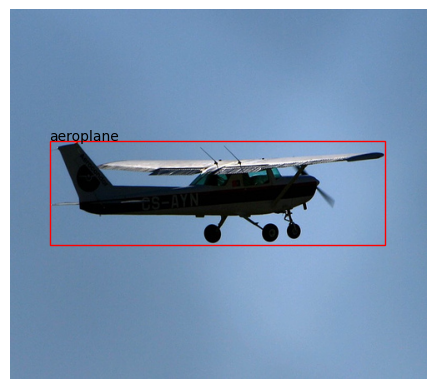

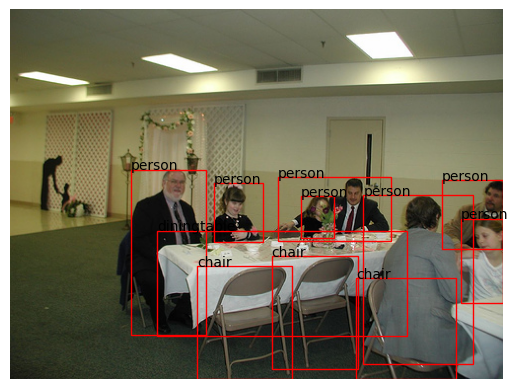

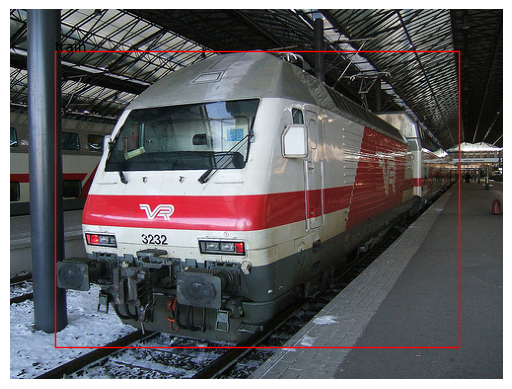

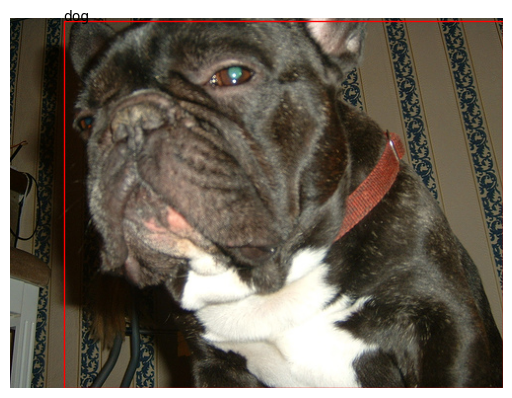

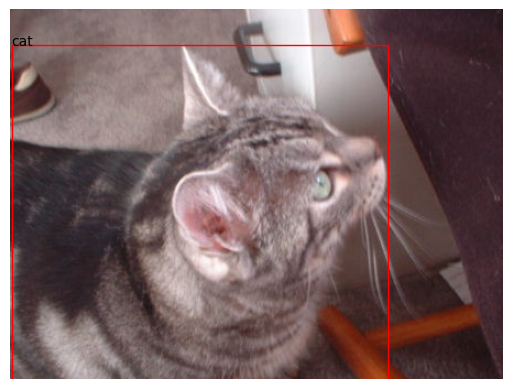

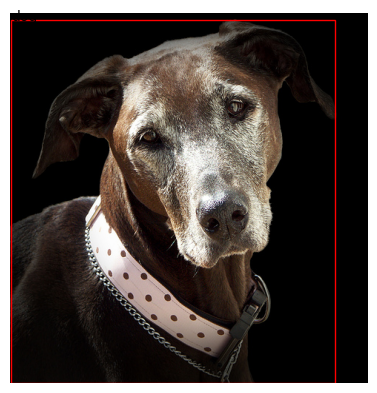

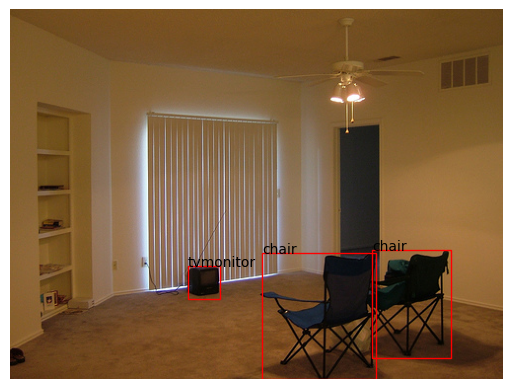

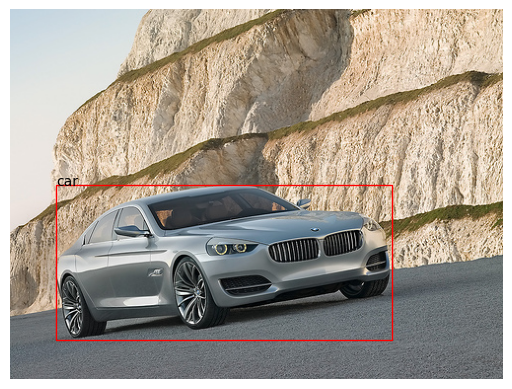

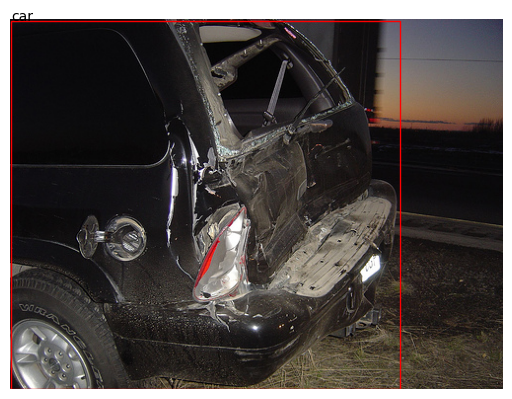

In [7]:
N_IMAGES = 16
for i in range(N_IMAGES):
    img, targets = dataset[i]

    img_size = img.size

    boxes = targets["boxes"]
    labels = targets["labels"]

    fig, ax = plt.subplots()
    ax.imshow(img)

    for i, box in enumerate(boxes):
        box = cxcywh_to_xywh(box.numpy())
        box = to_img_scale(box, img_size)  
        
        rect = patches.Rectangle((box[0], box[1]), box[2], box[3], linewidth=1, edgecolor="r", facecolor="none")
        ax.add_patch(rect)
        name = dataset.class_idx_to_name[labels[i].item()]
        ax.text(box[0], box[1], name)
        ax.axis("off")

    plt.show()

## Visualizing training data (with data augmentation)

In [8]:
def denormalize(img: torch.Tensor) -> np.ndarray:
    img = img.cpu().permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img * std + mean
    return np.clip(img, 0, 1)

In [9]:
dataset = VOC(ROOT, TRANSFORM, IMAGE_SET, DOWNLOAD)

In [10]:
print(f"VOCDetection training set with: {len(dataset)} samples")

VOCDetection training set with: 16551 samples


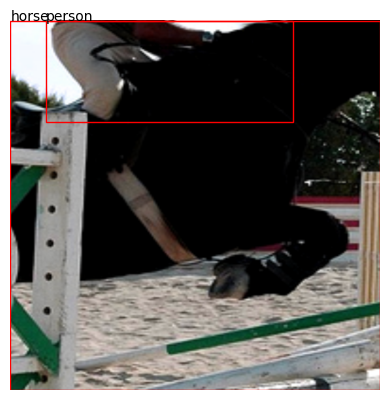

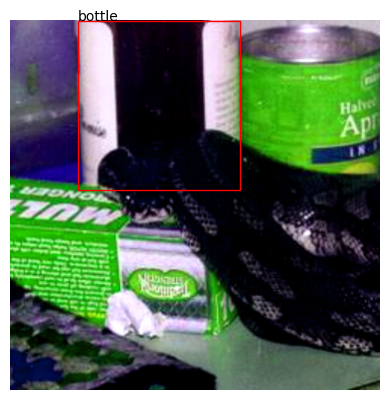

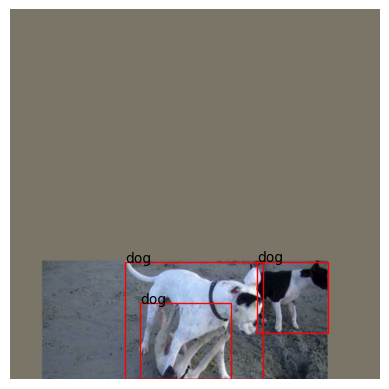

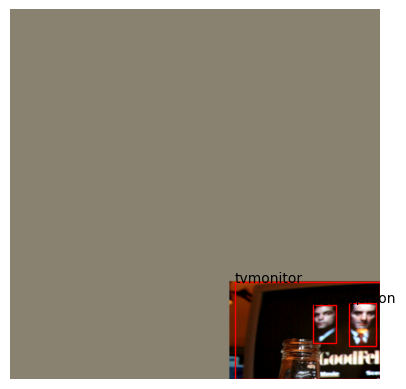

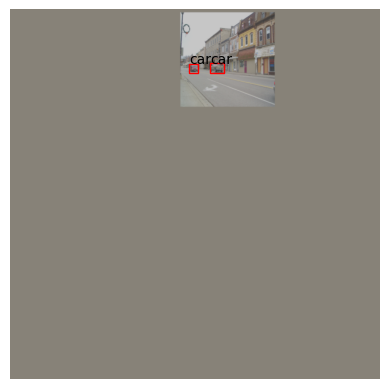

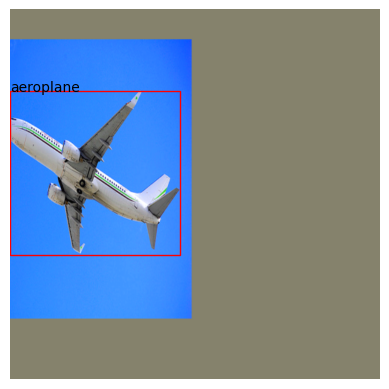

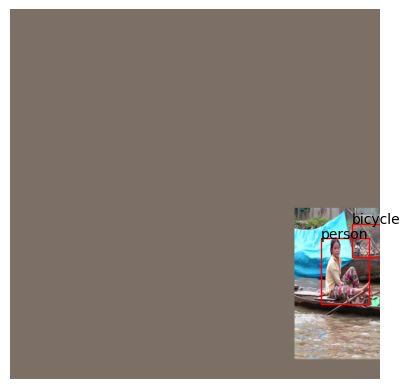

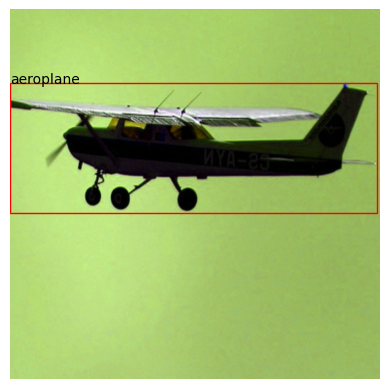

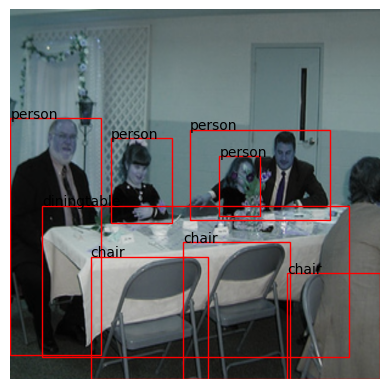

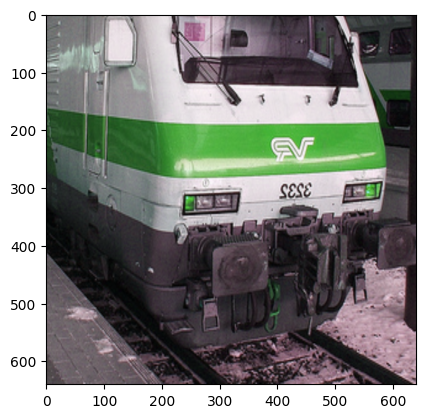

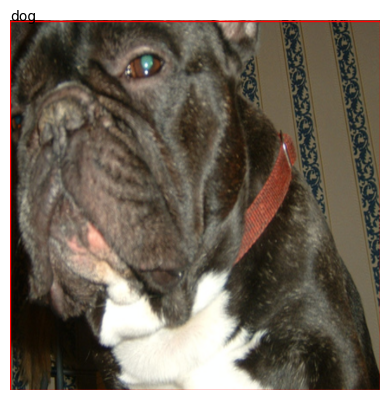

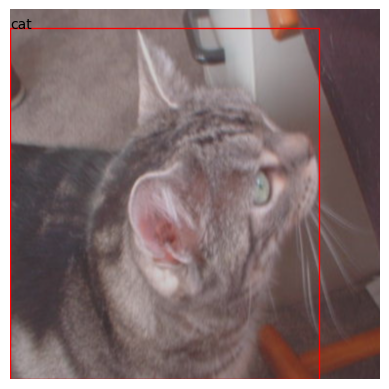

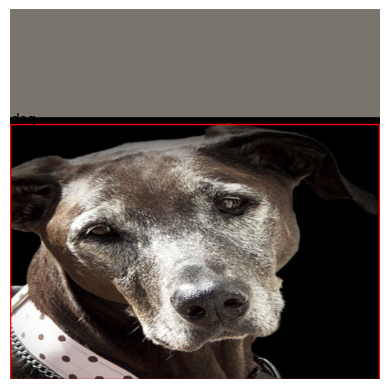

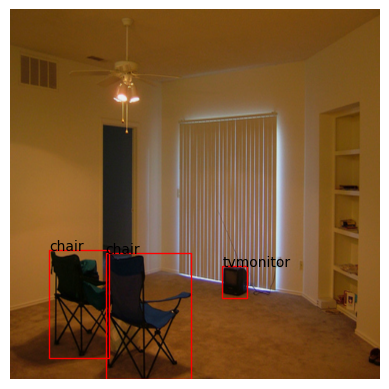

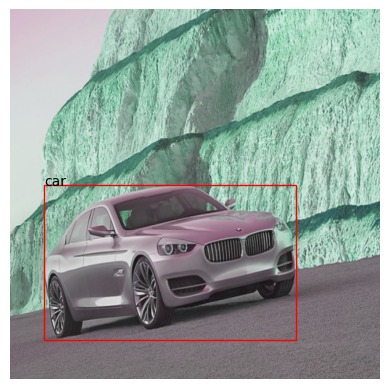

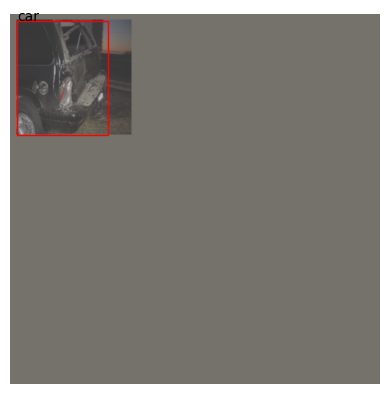

In [11]:
N_IMAGES = 16
for i in range(N_IMAGES):
    img, targets = dataset[i]
    img = denormalize(img)

    h, w, _ = img.shape
    img_size = (w, h)

    boxes = targets["boxes"]
    labels = targets["labels"]

    fig, ax = plt.subplots()
    ax.imshow(img)

    for i, box in enumerate(boxes):
        box = cxcywh_to_xywh(box.numpy())
        
        box[0] *= img_size[0]
        box[1] *= img_size[1]
        box[2] *= img_size[0]
        box[3] *= img_size[1]
        
        rect = patches.Rectangle((box[0], box[1]), box[2], box[3], linewidth=1, edgecolor="r", facecolor="none")
        ax.add_patch(rect)
        name = dataset.class_idx_to_name[labels[i].item()]
        ax.text(box[0], box[1], name)
        ax.axis("off")

    plt.show()